In [16]:
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
from anndata import AnnData
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


In [2]:

with h5py.File("data/tonsil_embedded.h5mu", "r") as f:
    print(list(f.keys()))
    if "mod" in f:
        print("mod keys:", list(f["mod"].keys()))

with h5py.File("data/tonsil_embedded.h5mu", "r") as f:
    print("mod/RNA keys:", list(f["mod/RNA"].keys()))


['mod', 'obs', 'obsm', 'obsmap', 'obsp', 'uns', 'var', 'varm', 'varmap', 'varp']
mod keys: ['Protein', 'RNA']
mod/RNA keys: ['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']


In [3]:

def load_rna_from_h5mu(h5mu_path, modality="RNA"):
    with h5py.File(h5mu_path, "r") as f:
        g = f[f"mod/{modality}"]

        # ---- Load X (dense or sparse) ----
        if isinstance(g["X"], h5py.Group):  
            indptr = np.array(g["X"]["indptr"])
            indices = np.array(g["X"]["indices"])
            data = np.array(g["X"]["data"])
            shape = tuple(g["X"]["shape"])
            X = sp.csr_matrix((data, indices, indptr), shape=shape)
        else:
            X = np.array(g["X"])

        # ---- Load obs safely ----
        obs_index = np.array(g["obs"]["_index"]).astype(str)
        n_obs = len(obs_index)

        obs = pd.DataFrame(index=obs_index)

        for key in g["obs"].keys():
            if key == "_index":
                continue

            arr = np.array(g["obs"][key])

            if arr.shape[0] == n_obs:
                obs[key] = arr.astype(str)
            else:
                print(f"Skipping obs field '{key}' (shape {arr.shape})")

        # ---- Load var ----
        var = pd.DataFrame(index=np.array(g["var"]["_index"]).astype(str))

        # ---- Load obsm ----
        obsm = {}
        if "obsm" in g:
            for key in g["obsm"].keys():
                obsm[key] = np.array(g["obsm"][key])

        # ---- Load varm ----
        varm = {}
        if "varm" in g:
            for key in g["varm"].keys():
                varm[key] = np.array(g["varm"][key])

        # ---- Load uns ----
        uns = {}
        if "uns" in g:
            for key in g["uns"].keys():
                try:
                    uns[key] = np.array(g["uns"][key])
                except:
                    uns[key] = dict(g["uns"][key])

    return AnnData(X=X, obs=obs, var=var, obsm=obsm, varm=varm, uns=uns)


In [4]:

with h5py.File("data/tonsil_embedded.h5mu", "r") as f:
    print("mod/RNA keys:", list(f["mod/RNA"].keys()))

    print("\nobs keys:", list(f["mod/RNA/obs"].keys()))
    print("var keys:", list(f["mod/RNA/var"].keys()))

    if "obsm" in f["mod/RNA"]:
        print("obsm keys:", list(f["mod/RNA/obsm"].keys()))


mod/RNA keys: ['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']

obs keys: ['_index', 'kmeans5', 'leiden', 'leiden_eval', 'louvain_eval']
var keys: ['_index']
obsm keys: ['X_pca', 'X_spatial_totalVI', 'X_umap', 'pos']


In [5]:
rna = load_rna_from_h5mu("data/tonsil_embedded.h5mu")
rna


Skipping obs field 'kmeans5' (shape (2,))
Skipping obs field 'leiden' (shape (2,))
Skipping obs field 'leiden_eval' (shape (2,))
Skipping obs field 'louvain_eval' (shape (2,))


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/421212535.py:13: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  X = np.array(g["X"])
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/421212535.py:16: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  obs_index = np.array(g["obs"]["_index"]).astype(str)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/421212535.py:33: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  var = pd.DataFrame(index=np.array(g["var"]["_index"]).astype(str))
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/421212535.py:39: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  obsm[key] = np.array(g[

AnnData object with n_obs × n_vars = 2492 × 2000
    uns: 'kmeans5_colors', 'leiden', 'leiden_colors', 'leiden_eval', 'leiden_eval_colors', 'louvain_eval', 'louvain_eval_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_spatial_totalVI', 'X_umap', 'pos'
    varm: 'PCs'

In [6]:
rna.obs_names[:10].tolist()

['29x42',
 '44x36',
 '34x6',
 '42x19',
 '41x6',
 '41x39',
 '49x13',
 '25x28',
 '12x1',
 '16x11']

In [9]:
latents = pd.read_csv("data/latents_sptotalvi.tsv", sep="\t", header=None)
latents.index = rna.obs_names  # attach correct cell IDs
rna.obsm["X_latent"] = latents.values
latents.head()

latents.index[:10].tolist()


['29x42',
 '44x36',
 '34x6',
 '42x19',
 '41x6',
 '41x39',
 '49x13',
 '25x28',
 '12x1',
 '16x11']

In [10]:
latents.shape, rna.shape

((2492, 20), (2492, 2000))

In [11]:
def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)


In [12]:
rna.obs["row_batch"] = rna.obs_names.str.extract(r"(\d+)x")[0].astype(int)
rna.obs["col_batch"] = rna.obs_names.str.extract(r"x(\d+)")[0].astype(int)

In [13]:
from sklearn.cluster import KMeans
rna.obs["cluster10"] = KMeans(n_clusters=10).fit_predict(rna.obsm["X_latent"])

In [14]:
rna.obs["iLISI"] = compute_lisi(rna.obsm["X_latent"], rna.obs["row_batch"])
rna.obs["cLISI"] = compute_lisi(rna.obsm["X_latent"], rna.obs["cluster10"])


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/965300063.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/965300063.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)


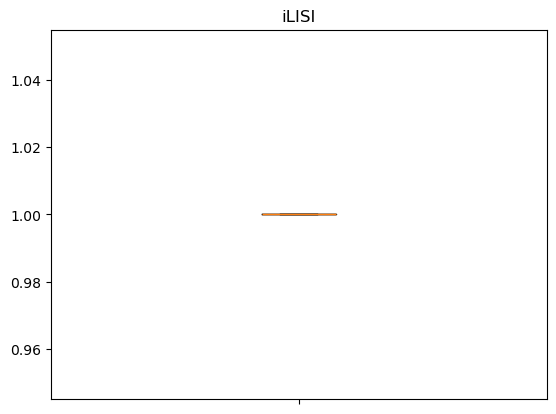

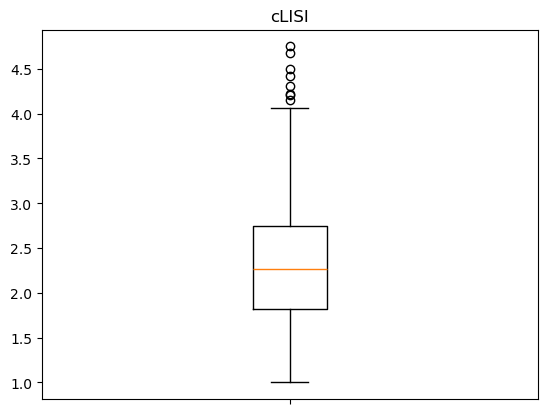

In [17]:
# iLISI score 1.0 because there are no batch labels, only obs/_index
plt.boxplot(rna.obs["iLISI"], tick_labels=[""])
plt.title("iLISI")
plt.show()

plt.boxplot(rna.obs["cLISI"], tick_labels=[""])
plt.title("cLISI")
plt.show()


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_90116/965300063.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)


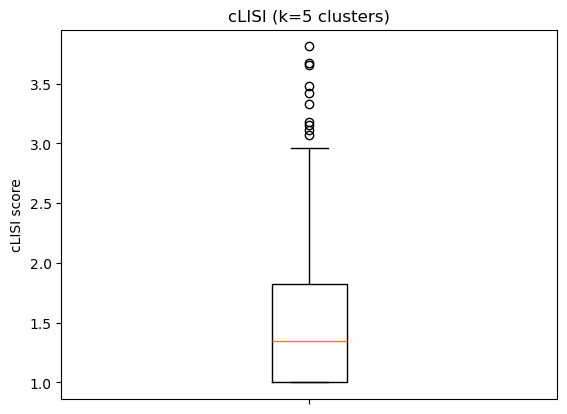

In [18]:
#  5 clusters from totalVI latent embedding 
rna.obs["cluster5"] = (
    KMeans(n_clusters=5, random_state=0)
    .fit_predict(rna.obsm["X_latent"])
)

# cLISI
rna.obs["cLISI_5"] = compute_lisi(
    rna.obsm["X_latent"],
    rna.obs["cluster5"]
)

plt.boxplot(rna.obs["cLISI_5"], tick_labels=[""])
plt.title("cLISI (k=5 clusters)")
plt.ylabel("cLISI score")
plt.show()
